In [ ]:
from ruamel.yaml import YAML
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
from torchvision.transforms import Compose, RandomRotation, Lambda, RandomCrop, Resize
from torchvision.transforms.functional import InterpolationMode
from torchvision.transforms.functional import gaussian_blur

from torch.utils.data import DataLoader
from torch.amp import autocast
from tqdm import tqdm

import seaborn as sns
import pandas as pd
from scipy.stats import pearsonr

import matplotlib.pyplot as plt

# set seeds
torch.manual_seed(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(0)
random.seed(0)

from multiplex_model.data import DatasetFromTIFF, PanelBatchSampler, TestCrop
from multiplex_model.losses import nll_loss
from multiplex_model.utils import ClampWithGrad, plot_reconstructs_with_uncertainty, get_scheduler_with_warmup
from multiplex_model.modules import MultiplexAutoencoder

from scipy.ndimage import gaussian_filter
from tifffile import imread
import gc
from copy import copy

device = 'cuda:0' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Using device: {device}')

SIZE = (128, 128)
BATCH_SIZE = 1
NUM_WORKERS = 4

PANEL_CONFIG = YAML().load(open('configs/all_panels_config.yaml'))
TOKENIZER = YAML().load(open('configs/all_markers_tokenizer.yaml'))
INV_TOKENIZER = {v: k for k, v in TOKENIZER.items()}

train_transform = Compose([
    RandomRotation(
        180, 
        interpolation=InterpolationMode.BILINEAR
    ),
    RandomCrop(SIZE),
])

test_transform = TestCrop(SIZE[0])

# train_dataset = DatasetFromTIFF(
#     panels_config=PANEL_CONFIG,
#     # split='train',
#     split="all",
#     marker_tokenizer=TOKENIZER,
#     transform=test_transform,
#     use_median_denoising=False,
#     use_butterworth_filter=True,
#     use_clip_normalization=True,
#     use_minmax_normalization=False,
#     clip_per_dataset=True,
    
# )

test_dataset = DatasetFromTIFF(
    panels_config=PANEL_CONFIG,
    split='test',
    marker_tokenizer=TOKENIZER,
    # transform=test_transform,
    use_median_denoising=False,
    use_butterworth_filter=True,
    use_clip_normalization=True,
    use_minmax_normalization=False,
    plot=False,
    clip_per_dataset=True
)

# train_batch_sampler = PanelBatchSampler(train_dataset, BATCH_SIZE, shuffle=False)
test_batch_sampler = PanelBatchSampler(test_dataset, BATCH_SIZE, shuffle=False)

# train_dataloader = DataLoader(train_dataset, batch_sampler=train_batch_sampler, num_workers=NUM_WORKERS)
test_dataloader = DataLoader(test_dataset, batch_sampler=test_batch_sampler, num_workers=NUM_WORKERS)

model_config = YAML().load(open("/raid_encrypted/immucan/models/config.ImmuVis-768_model.yaml"))
model_config = {
        'num_channels': len(TOKENIZER),
        'encoder_config': model_config['encoder'],
        'decoder_config': model_config['decoder'],
    }


model = MultiplexAutoencoder(**model_config).to(device)
model.load_state_dict(torch.load('/raid_encrypted/immucan/models/ImmuVis-768_model-UN-475.pth', map_location=device)['model_state_dict'])
model.eval()

Using device: cuda:0


MultiplexAutoencoder(
  (encoder): MultiplexImageEncoder(
    (marker_agnostic_encoder): ConvNeXtEncoder(
      (norm_poolings): ModuleList(
        (0): Sequential(
          (0): Conv2d(1, 16, kernel_size=(2, 2), stride=(2, 2))
          (1): LayerNorm()
        )
      )
      (blocks): ModuleList(
        (0): Sequential(
          (0): ConvNextBlock(
            (conv1): Conv2d(16, 16, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=16)
            (ln): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
            (conv2): Linear(in_features=16, out_features=64, bias=True)
            (act): GELU(approximate='none')
            (grn): GlobalResponseNormalization()
            (conv3): Linear(in_features=64, out_features=16, bias=True)
          )
          (1): ConvNextBlock(
            (conv1): Conv2d(16, 16, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=16)
            (ln): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
            (conv2): Line

In [2]:
for p in model.parameters():
    p.requires_grad = False

In [3]:
# res_df = []
# for f in tqdm(os.listdir("/raid_encrypted/immucan/IMC/SHCN/IMC1/csv")):
#     # print(f)
#     df = pd.read_csv("/raid_encrypted/immucan/IMC/SHCN/IMC1/csv/"+f)
#     if "image" in df.columns:
#     #     # print(df["image"][0])
#         res_df.append(df)
#     #     if "IMMUcan_Batch20230329_10104735-SPECT-VAR-TIS-01-IMC-01_002.tiff" in df["image"].to_list():
#     #         print(f)
# res_df = pd.concat(res_df, ignore_index=True)

In [4]:
# res_df.to_csv("hn_sc_metadata.csv", index=False)

In [5]:
# metadata_df = pd.read_csv("/raid_encrypted/immucan/IMC/SHCN/IMC1/csv/IMMU-SCCHN1-1359-FIXT-01-IMC1-01_#_IMMUcan_panel_1_1.11_#_cell_metadata_#_8652a67d5d006a928684e98306fc7c79.csv")
# metadata_df = metadata_df[metadata_df["image"] == "IMMUcan_Batch20230329_10104735-SPECT-VAR-TIS-01-IMC-01_002.tiff"]
# metadata_df

In [6]:
metadata_df = pd.read_csv("hn_sc_metadata.csv")

In [7]:
split_df = pd.read_csv("../split_dec.csv")
res_metadata_df = []

In [8]:
from copy import copy
from captum.attr import *
from torch.optim import *

In [9]:
class ImmuvisWrapper(nn.Module):
    def __init__(self, model: MultiplexAutoencoder, target_channels: tuple):
        super().__init__()
        self.model = model
        self.target_channels = target_channels

    def set_channels(self, encoded_indices: torch.Tensor, decoded_indices: torch.Tensor):
        self.encoded_indices = encoded_indices
        self.decoded_indices = decoded_indices

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.model(x, self.encoded_indices, self.decoded_indices)["output"]  # [B, C, H, W, 2]
        mi_logits = out[..., 0]
        score = torch.sigmoid(mi_logits)[:, self.target_channels].mean((-2,-1))  # [B]
        score = score.mean((-1), keepdim=True)  # [B, 1]
        return score

  0%|          | 0/500 [00:00<?, ?it/s]

0.04052734375


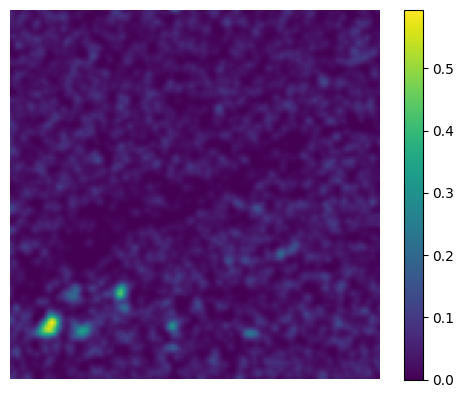

 10%|█         | 50/500 [00:10<01:28,  5.11it/s, Sum change=0.000126, PDL1=0.0369]

0.036865234375


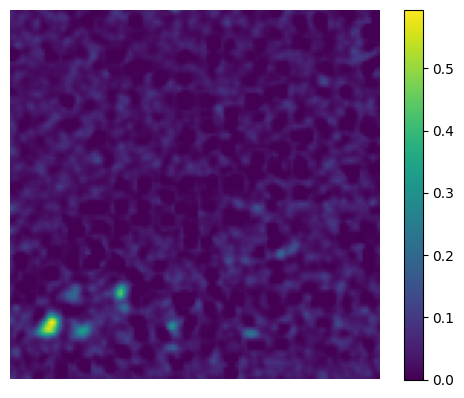

 20%|██        | 100/500 [00:20<01:18,  5.10it/s, Sum change=0.000124, PDL1=0.0354]

0.035400390625


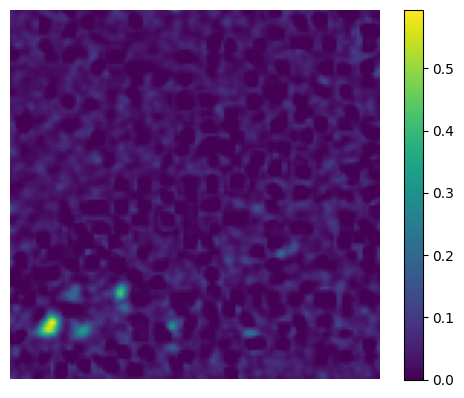

 30%|███       | 150/500 [00:30<01:08,  5.09it/s, Sum change=0.000119, PDL1=0.0361]

0.0361328125


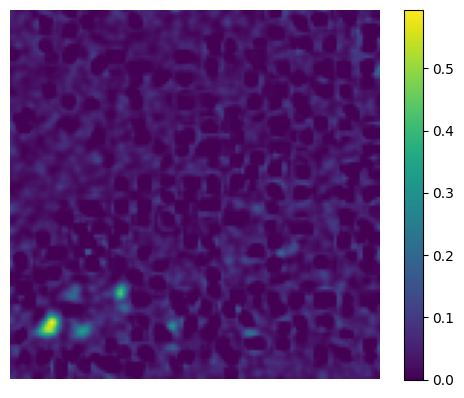

 40%|████      | 200/500 [00:40<01:00,  4.94it/s, Sum change=0.000123, PDL1=0.0374]

0.037353515625


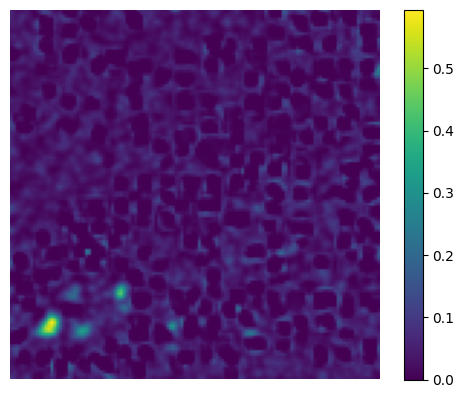

 46%|████▌     | 228/500 [00:46<00:56,  4.84it/s, Sum change=0.000123, PDL1=0.0381]Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x73730c0cd190>>
Traceback (most recent call last):
  File "/home/pkupidura/immuvis/virtues/virt_env/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 
 50%|█████     | 250/500 [00:51<00:58,  4.27it/s, Sum change=0.000124, PDL1=0.0386]

0.03857421875


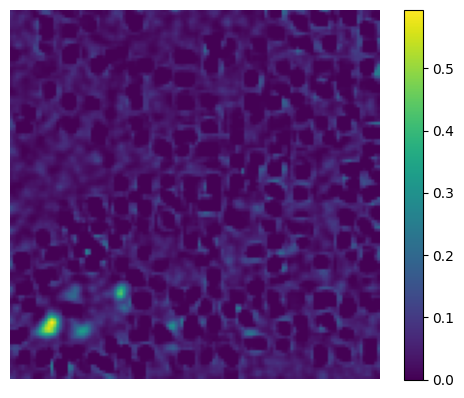

 56%|█████▋    | 282/500 [00:58<00:46,  4.67it/s, Sum change=0.000119, PDL1=0.0391]

In [ ]:
res_metadata_df = []
for batch_idx, (img, channel_ids, panel_idx, img_path) in enumerate(test_dataloader):
    if img_path[0] != "/raid_encrypted/immucan/IMC/immu-vis-other-ds/full-20122025/3553.tiff":
        continue
    old_path = split_df[split_df["new_path"] == img_path[0]]["tiff_path"].values[0]
    if "/raid_encrypted" not in old_path:
        old_path = old_path.replace("/raid", "/raid_encrypted")
    tcf7_pre, tcf7_post = [], []
    markers_post = copy(PANEL_CONFIG["markers"][panel_idx[0]])
    markers_post.remove("PD1")
    markers_post.remove("PDL1")
    pre = dict(zip(PANEL_CONFIG["markers"][panel_idx[0]], [[] for _ in range(channel_ids.shape[1])]))
    post = dict(zip(markers_post, [[] for _ in range(channel_ids.shape[1])]))
    # plt.imshow(img[0,34])
    # plt.show()
    # plt.imshow(img[0,36])
    # plt.show()
    # break

    clip_limit = PANEL_CONFIG["clip_limits"][panel_idx[0]]

    img = img[:,:,:128,:128]
    batch_size, num_channels, H, W = img.shape
    img = img.to(device)
    channel_ids = channel_ids.to(device)

    channels_subset_indices = torch.where(torch.logical_or(channel_ids == channel_ids[0,34], 
                                                           channel_ids == channel_ids[0,36]), 1, 0)
    channels_subset_indices = torch.masked_select(torch.arange(num_channels).to(device),
                                                   channels_subset_indices.to(device)==0).reshape(batch_size, -1)

    channels_subset_indices = channels_subset_indices.unsqueeze(-1).unsqueeze(-1).expand(-1, -1, H, W)  # Shape: [batch_size, num_sampled_channels, H, W]
    masked_img = torch.gather(img, dim=1, index=channels_subset_indices).to(device).to(torch.bfloat16)

    # Gather corresponding channel IDs
    active_channel_ids = torch.gather(channel_ids, dim=1, index=channels_subset_indices[:, :, 0, 0])
    accum_grad = 0
    mask = imread(f"/raid_encrypted/immucan/IMC/SHCN/IMC1/zip/masks/{old_path.split('/')[-1]}")[:128,:128]
    metadata_df_img = metadata_df[metadata_df["image"] == old_path.split("/")[-1]]
    c_ind = 25
    for i in metadata_df_img["ObjectNumber"]:
        cell = img[0,:,mask==i].mean(-1)
        if i not in np.unique(mask):
            for m in pre:
                pre[m].append(np.nan)
        else:
            for k,m in enumerate(pre):
                pre[m].append(cell[k].item())

    for m in pre:
        metadata_df_img[f"{m.lower().replace(" ","_")}_pre"] = pre[m]

    pbar = tqdm(range(500))
    optimizer = AdamW([masked_img], lr=1e-3, weight_decay=0.0)
    masked_img.requires_grad = True
    for i in pbar:

        with autocast(device_type=device, dtype=torch.bfloat16):
            output = model(masked_img, active_channel_ids, channel_ids)['output']
            mi, logsigma = output.unbind(dim=-1)
            mi = torch.sigmoid(mi).float()
            logsigma = logsigma.float()
            pd1 = mi[0,36].mean()
            grad = torch.autograd.grad(pd1, masked_img, retain_graph=False)[0]

            # wrapper = ImmuvisWrapper(model, target_channels=(36,))
            # wrapper.set_channels(active_channel_ids, channel_ids)
            # baseline = torch.zeros_like(masked_img).to(device)
            # baseline = torch.rand_like(masked_img).to(device)
            # baseline = torch.ones_like(masked_img).to(device) * masked_img.mean()
            # ig = DeepLift(wrapper)
            # grad, delta = ig.attribute(masked_img, baseline, target=0, return_convergence_delta=True)
            # grad = ig.attribute(masked_img)
            # print("Convergence delta:", delta)
            topk_mask = []
            for c in range(grad.shape[1]):
                topk_mask.append(torch.zeros_like(masked_img[:,c]).masked_scatter(grad[:,c].abs() > grad[:,c].abs().to(torch.float32).quantile(0.9), torch.ones_like(masked_img[:,c])).bool())
            topk_mask = torch.stack(topk_mask, dim=1)
            # topk_mask = torch.zeros_like(masked_img).masked_scatter(grad.abs() > grad.abs().to(torch.float32).quantile(0.9), torch.ones_like(masked_img)).bool()
            grad *= topk_mask
            # grad = gaussian_filter(grad.to(torch.float32).numpy(force=True), sigma=1.3)
            grad = gaussian_blur(grad, kernel_size=5, sigma=1.5)
            pd1 = masked_img[0,36].mean()
            # if i % 50 == 0:
            #     print(pd1.item())
            #     plt.imshow(masked_img[0,c_ind].to(torch.float16).numpy(force=True))
            #     plt.colorbar()
            #     plt.axis("off")
            #     plt.show()
            #     plt.close()

            # print(grad.shape)
            # plt.imshow(grad[0].to(torch.float16).numpy(force=True))
            # plt.colorbar()
            # plt.axis("off")
            # plt.show()

            masked_img_pre = masked_img.clone()
            # update = 1500 * grad.to(torch.bfloat16)
            # masked_img = masked_img + update
            masked_img.grad = grad.to(torch.bfloat16)
            # print(grad.pow(2).mean().item())
            optimizer.step()
            masked_img.data = torch.clamp(masked_img, 0, 1)
            # masked_img = gaussian_blur(masked_img, kernel_size=9, sigma=0.2)
            masked_img.grad = torch.zeros_like(masked_img)
            # print(masked_img.shape, channel_ids.shape)
            accum_grad += (masked_img - masked_img_pre)
            # masked_img = masked_img.to(torch.float16)
            # masked_img = masked_img.detach()

            torch.cuda.empty_cache()
            torch.clear_autocast_cache()
            gc.collect()

            pbar.set_postfix({"Sum change" :(masked_img - masked_img_pre).abs().mean().item(),
                              "PDL1": pd1.item()})
        



    # plt.imshow(accum_grad[0,c_ind].to(torch.float16).numpy(force=True))
    # plt.colorbar()
    # plt.axis("off")
    # plt.show()
    importance = dict(zip(markers_post, [[] for _ in range(masked_img.shape[1])]))
    for i in metadata_df_img["ObjectNumber"]:
        cell = masked_img[0,:,mask==i].mean(-1)
        imp_cell = accum_grad[0,:,mask==i].mean(-1)
        if i not in np.unique(mask):
            for m in post:
                post[m].append(np.nan)
                importance[m].append(np.nan)
        else:
            for k,m in enumerate(post):
                post[m].append(cell[k].item())
                importance[m].append(imp_cell[k].item())
    for m in post:
        metadata_df_img[f"{m.lower().replace(" ","_")}_post"] = post[m]
    for m in markers_post:
        metadata_df_img[f"{m.lower().replace(" ","_")}_fc"] = metadata_df_img[f"{m.lower().replace(" ","_")}_post"]/metadata_df_img[f"{m.lower().replace(" ","_")}_pre"]
        metadata_df_img[f"{m.lower().replace(" ","_")}_importance"] = importance[m]
    res_metadata_df.append(metadata_df_img)
    break
res_metadata_df = pd.concat(res_metadata_df, ignore_index=True)
res_metadata_df = res_metadata_df.replace([np.inf, -np.inf], np.nan)

In [ ]:
print(res_metadata_df.groupby("celltypes")["cl.parp_fc"].mean().apply(np.log2))
print(res_metadata_df.groupby("celltypes")["cl.parp_importance"].mean())

celltypes
B             6.216651
BnT           6.533484
CD4           5.138173
CD8           5.220749
DC            4.892706
HLADR         6.492181
MacCD163      5.337802
Mural         7.290688
NK            5.685651
Neutrophil    6.734780
Treg          5.469095
Tumor         3.553543
pDC           2.707869
plasma        3.718317
undefined     7.254085
Name: cl.parp_fc, dtype: float64
celltypes
B             0.003518
BnT           0.003486
CD4           0.001899
CD8           0.001973
DC            0.001503
HLADR         0.002279
MacCD163      0.000829
Mural         0.002941
NK            0.003961
Neutrophil    0.002907
Treg          0.002108
Tumor        -0.000082
pDC          -0.000132
plasma        0.000463
undefined     0.001158
Name: cl.parp_importance, dtype: float64


In [ ]:
res_metadata_df["celltypes"].value_counts()

celltypes
Tumor         100789
CD8            19440
Mural          18621
BnT            12725
CD4            12452
MacCD163       10993
plasma         10595
Neutrophil     10170
Treg            9834
B               6474
HLADR           5753
pDC             4110
undefined       3951
DC              3937
NK              1078
Name: count, dtype: int64

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

res_metadata_df = pd.read_csv("xai_hn/sc_hn_merged.csv")

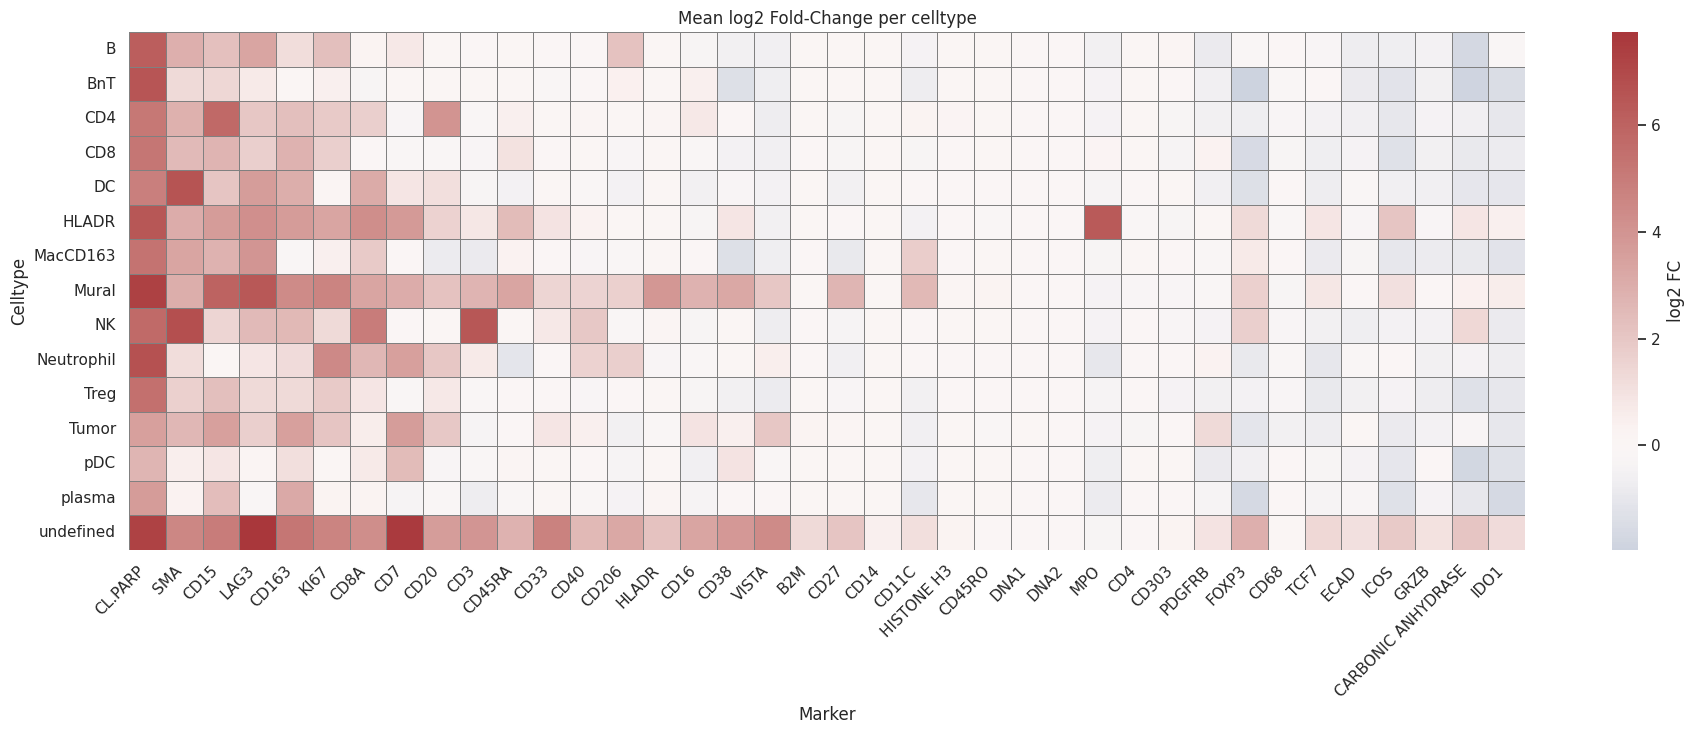

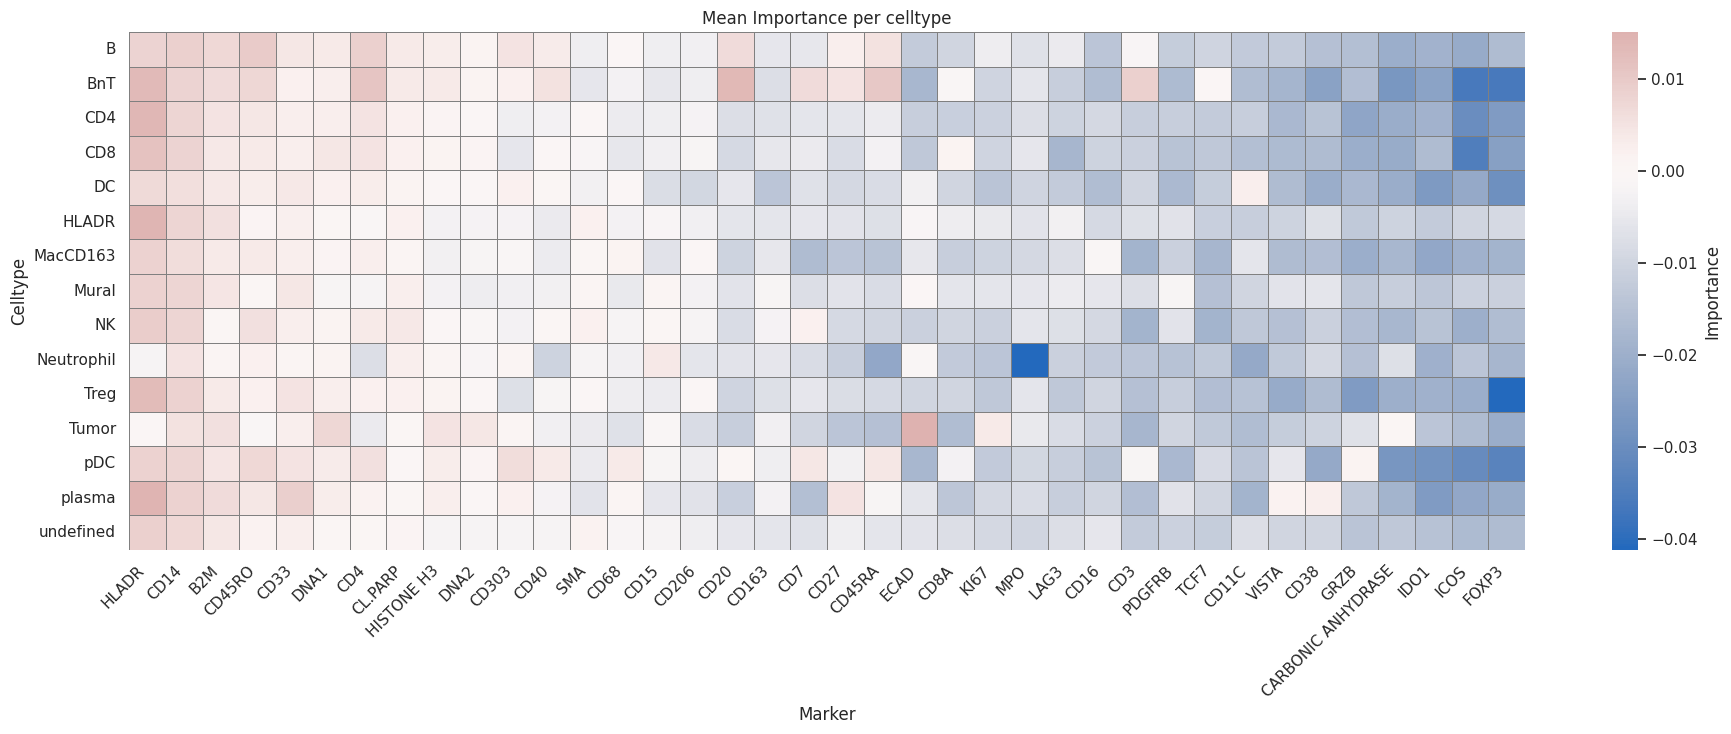

In [ ]:
import seaborn as sns

fc_cols = [c for c in res_metadata_df.columns if c.endswith('_fc')]
df_fc = res_metadata_df.groupby('celltypes')[fc_cols].mean()

df_fc_safe = df_fc.replace([0], np.nan)
df_log2 = np.log2(df_fc_safe)

col_order = df_log2.mean(axis=0).sort_values(ascending=False).index.tolist()
df_log2 = df_log2[col_order]

display_cols = [c[:-3].replace('_', ' ').upper() for c in df_log2.columns]
df_log2.columns = display_cols

plt.figure(figsize=(max(8, len(display_cols)*0.5), max(6, df_log2.shape[0]*0.5)))
sns.set(style='white')
ax = sns.heatmap(df_log2, cmap='vlag', center=0, linewidths=0.5, linecolor='gray', cbar_kws={'label': 'log2 FC'})
ax.set_xlabel('Marker')
ax.set_ylabel('Celltype')
plt.xticks(rotation=45, ha='right')
plt.title('Mean log2 Fold-Change per celltype')
plt.tight_layout()
plt.show()

df_importance = res_metadata_df.groupby('celltypes')[[c for c in res_metadata_df.columns if c.endswith('_importance')]].mean()
col_order = df_importance.mean(axis=0).sort_values(ascending=False).index.tolist()
df_importance = df_importance[col_order]
display_cols = [c[:-11].replace('_', ' ').upper() for c in df_importance.columns]
df_importance.columns = display_cols
plt.figure(figsize=(max(8, len(display_cols)*0.5), max(6, df_importance.shape[0]*0.5)))
sns.set(style='white')
ax = sns.heatmap(df_importance, cmap='vlag', center=0, linewidths=0.5, linecolor='gray', cbar_kws={'label': 'Importance'})
ax.set_xlabel('Marker')
ax.set_ylabel('Celltype')
plt.xticks(rotation=45, ha='right')
plt.title('Mean Importance per celltype')
plt.tight_layout()
plt.show()

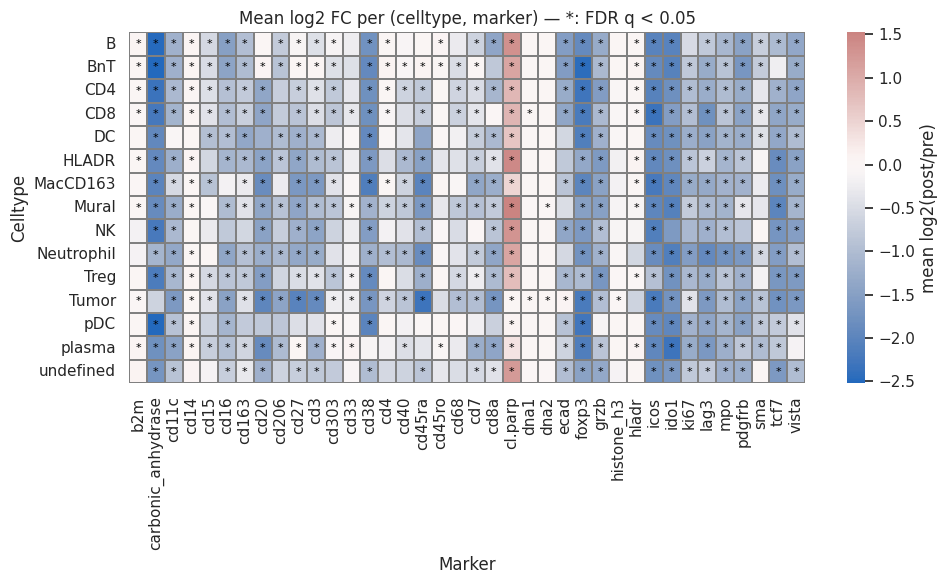

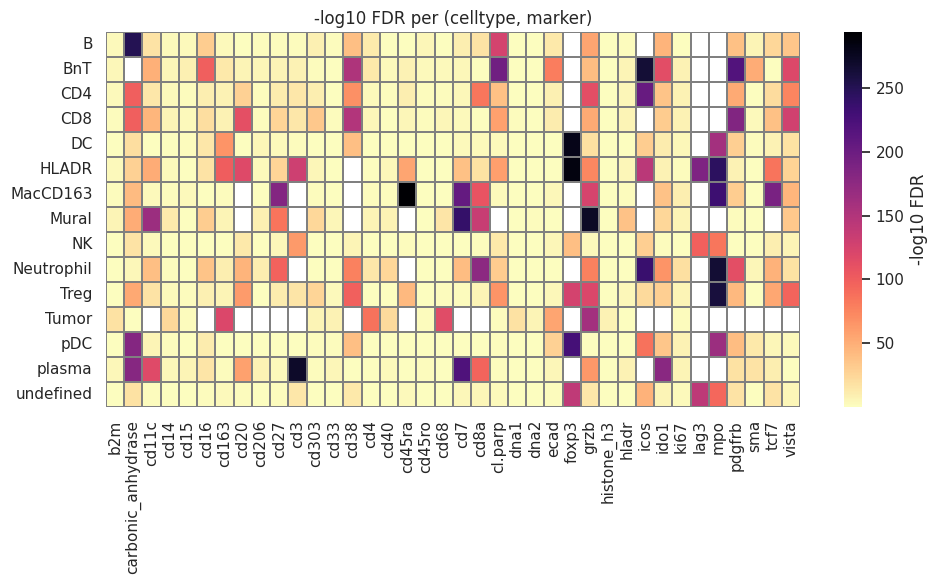

In [ ]:
from statsmodels.stats.multitest import multipletests
from scipy.stats import ttest_ind
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# derive marker base names present in the dataframe (columns like 'xxx_pre' / 'xxx_post')
bases = sorted({col[:-4] for col in res_metadata_df.columns if col.endswith('_pre')})
bases.remove("pd1")
bases.remove("pdl1")

celltypes = sorted(res_metadata_df['celltypes'].dropna().unique())

# DataFrame to store raw p-values
pvals = pd.DataFrame(index=celltypes, columns=bases, dtype=float)

# compute t-tests per (celltype, marker)
for ct in celltypes:
    sub = res_metadata_df[res_metadata_df['celltypes'] == ct]
    for b in bases:
        pre = sub[f"{b}_pre"].dropna()
        post = sub[f"{b}_post"].dropna()
        if len(pre) < 2 or len(post) < 2:
            pvals.at[ct, b] = np.nan
        else:
            _, p = ttest_ind(pre, post, equal_var=False)  # Welch's t-test
            pvals.at[ct, b] = p

# FDR correction across all tests (ignore NaNs)
pvals_flat = pvals.values.flatten()
valid_mask = ~np.isnan(pvals_flat)
adj_flat = np.full_like(pvals_flat, np.nan, dtype=float)

rej, adj_pvals_nonan, _, _ = multipletests(pvals_flat[valid_mask], method='fdr_bh')
adj_flat[valid_mask] = adj_pvals_nonan
adj_pvals = pd.DataFrame(adj_flat.reshape(pvals.shape), index=pvals.index, columns=pvals.columns)

# compute mean log2 fold-change per celltype x marker for plotting (safe to compute here)
# avoid zeros by replacing 0 with nan
log2fc = pd.DataFrame(index=celltypes, columns=bases, dtype=float)
for ct in celltypes:
    sub = res_metadata_df[res_metadata_df['celltypes'] == ct]
    for b in bases:
        pre = sub[f"{b}_pre"].replace(0, np.nan)
        post = sub[f"{b}_post"].replace(0, np.nan)
        vals = np.log2(post / pre)
        log2fc.at[ct, b] = vals.mean()

# Heatmap: log2 fold-change with '*' where adj_p < 0.05
plt.figure(figsize=(max(10, len(bases) * 0.25), max(6, len(celltypes) * 0.25)))
ax = sns.heatmap(log2fc.astype(float), cmap='vlag', center=0, linewidths=0.3, linecolor='gray',
                 cbar_kws={'label': 'mean log2(post/pre)'}, xticklabels=True, yticklabels=True)
ax.set_xlabel('Marker')
ax.set_ylabel('Celltype')
plt.xticks(rotation=90)

# overlay significance stars
for i, ct in enumerate(log2fc.index):
    for j, b in enumerate(log2fc.columns):
        p_adj = adj_pvals.at[ct, b]
        if not np.isnan(p_adj) and p_adj < 0.05:
            ax.text(j + 0.5, i + 0.5, '*', ha='center', va='center', color='black', fontsize=8)

plt.title('Mean log2 FC per (celltype, marker) — *: FDR q < 0.05')
plt.tight_layout()
plt.show()

# also show a -log10 FDR heatmap for effect strength
neglog_adj = -np.log10(adj_pvals.astype(float))
neglog_adj.replace([np.inf, -np.inf], np.nan, inplace=True)
plt.figure(figsize=(max(10, len(bases) * 0.25), max(6, len(celltypes) * 0.25)))
sns.heatmap(neglog_adj, cmap='magma_r', linewidths=0.3, linecolor='gray',
            cbar_kws={'label': '-log10 FDR'}, xticklabels=True, yticklabels=True)
plt.xticks(rotation=90)
plt.title('-log10 FDR per (celltype, marker)')
plt.tight_layout()
plt.show()

# Notes
### Regularize by distance from original image
### Butterworth on gradient
### Display cell masks colored by type